# Predicting PM2.5 levels across London from socio-demographic characteristics using a GNN

This report applies a GNN model (GraphSAGE) to predict PM2.5 levels across London wards using sociodemographic data. This could reveal important information about which groups are most vulnerable to high fine particulate pollutants, and where to prioritise interventions. 

## Installs

In [1]:

# Colab setup (uncomment if needed)
!pip install contextily
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip -q install torch-geometric
!pip -q install networkx numpy pandas matplotlib geopandas shapely pyproj rtree seaborn

import math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
import seaborn as sns
from scipy.stats import norm
import contextily as ctx
import pyproj
from matplotlib.ticker import FuncFormatter
import os
import torch
import torch.nn.functional as F

plt.rcParams["figure.dpi"] = 140

print("torch:", torch.__version__)

# PyG imports
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv, SAGEConv

torch: 2.10.0+cpu


## Loading and examining data

In [2]:
geojson_path = "C:/Users/caras/ATUA/Block2/URBAN5160-Graph-Modelling-and-spatial-explicit-GeoAI-for-Urban-Analytics/URBAN5160-Graph-Modelling-and-spatial-explicit-GeoAI-for-Urban-Analytics/Assignment/AssignmentData-LondonPM25Prediction.geojson"
gdf = gpd.read_file(geojson_path)
gdf.head()

,oa_code,PM25,k001_PCT,k002_PCT,k003_PCT,k004_PCT,k005_PCT,k006_PCT,k007_RATIO,k008_PCT,...,k052_PCT,k053_PCT,k054_PCT,k055_PCT,k056_PCT,k057_PCT,k058_PCT,k059_PCT,k060_PCT,geometry
0,E00023264,16.037363,0.655567,0.733280,0.788337,0.809438,0.616867,0.048672,0.497994,0.116873,...,0.801915,0.574316,0.565354,0.693873,0.607090,0.478002,0.509235,0.638862,0.662914,"MULTIPOLYGON (((527635.452 171810.058, 527495...."
1,E00003359,15.571575,0.747233,0.539689,0.833211,0.720010,0.659997,0.155885,0.389216,0.387319,...,0.731722,0.346726,0.750254,0.730786,0.669715,0.548814,0.621092,0.667940,0.558571,"MULTIPOLYGON (((543581.516 171132.486, 543704 ..."
2,E00023266,16.068834,0.689326,0.758308,0.780265,0.787414,0.633875,0.151961,0.542225,0.000000,...,0.789704,0.603182,0.551503,0.630910,0.562070,0.614731,0.500493,0.624021,0.682385,"MULTIPOLYGON (((526613.539 171839.165, 526546...."
3,E00020264,18.205215,0.749280,0.701306,0.841211,0.773311,0.432955,0.000000,0.480711,0.000000,...,0.712008,0.454649,0.413096,0.740138,0.831888,0.726281,0.377247,0.517599,0.540406,"MULTIPOLYGON (((533563.521 179695.146, 533351...."
4,E00023263,16.128491,0.716956,0.743201,0.823621,0.783315,0.621155,0.073256,0.532274,0.000000,...,0.752003,0.656612,0.372115,0.741299,0.555038,0.692244,0.524108,0.657307,0.614341,"MULTIPOLYGON (((527822 172020, 527979 171903.0..."


In [3]:
#checking gdf type, variable data types, shape of gdf
print(type(gdf))
print(gdf.dtypes)
print(gdf.shape)

<class 'geopandas.geodataframe.GeoDataFrame'>
oa_code       object
PM25         float64
k001_PCT     float64
k002_PCT     float64
k003_PCT     float64
              ...   
k057_PCT     float64
k058_PCT     float64
k059_PCT     float64
k060_PCT     float64
geometry    geometry
Length: 63, dtype: object
(25053, 63)


In [4]:
print(gdf.columns.tolist())

['oa_code', 'PM25', 'k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k009_PCT', 'k010_PCT', 'k011_PCT', 'k012_PCT', 'k013_PCT', 'k014_PCT', 'k015_PCT', 'k016_PCT', 'k017_PCT', 'k018_PCT', 'k019_PCT', 'k020_PCT', 'k021_PCT', 'k022_PCT', 'k023_PCT', 'k024_PCT', 'k025_PCT', 'k026_PCT', 'k027_PCT', 'k028_PCT', 'k029_PCT', 'k030_PCT', 'k031_PCT', 'k032_PCT', 'k033_PCT', 'k034_PCT', 'k035_RATIO', 'k036_PCT', 'k037_PCT', 'k038_PCT', 'k039_PCT', 'k040_PCT', 'k041_PCT', 'k042_PCT', 'k043_PCT', 'k044_PCT', 'k045_PCT', 'k046_PCT', 'k047_PCT', 'k048_PCT', 'k049_PCT', 'k050_PCT', 'k051_PCT', 'k052_PCT', 'k053_PCT', 'k054_PCT', 'k055_PCT', 'k056_PCT', 'k057_PCT', 'k058_PCT', 'k059_PCT', 'k060_PCT', 'geometry']


In [5]:
# Ensure geometry is valid; fix common issues where possible
gdf = gdf.copy()
gdf["geometry"] = gdf["geometry"].buffer(0)  # fixes many self-intersections
gdf = gdf[gdf.geometry.notnull()].reset_index(drop=True)

In [6]:
print(gdf.geometry.geom_type.value_counts())

Polygon         24933
MultiPolygon      120
Name: count, dtype: int64


In [7]:
print(gdf.crs)

EPSG:27700


In [8]:
print(gdf.dtypes.value_counts())

float64     61
object       1
geometry     1
Name: count, dtype: int64


In [9]:
gdf[['oa_code', "geometry"]].head()

,oa_code,geometry
0,E00023264,"POLYGON ((527635.452 171810.058, 527495.957 17..."
1,E00003359,"POLYGON ((543581.516 171132.486, 543704 171022..."
2,E00023266,"POLYGON ((526613.539 171839.165, 526546.84 171..."
3,E00020264,"POLYGON ((533563.521 179695.146, 533351.118 17..."
4,E00023263,"POLYGON ((527822 172020, 527979 171903.001, 52..."


In [10]:
gdf['PM25'].describe()

count    25053.000000
mean        15.975608
std          0.783971
min         14.283266
25%         15.403583
50%         15.846878
75%         16.428663
max         21.100099
Name: PM25, dtype: float64

## Data Visualisations and Descriptive Statistics 

Figure 1 and 2 shows the distribution of PM2.5 levels across London wards. These reveal that the data is moderately skewed to the right. The mean PM2.5 level is about 15.98, the minimum level is 14.28 μg/m3 and the max level is 21.1 μg/m3. 
Figure 3 shows PM2.5 spatial distribution. From the map, it can be seen that inner city wards and main roads have a higher concentration of PM2.5s than other areas. As expected, the more peripheral areas have lower levels. 

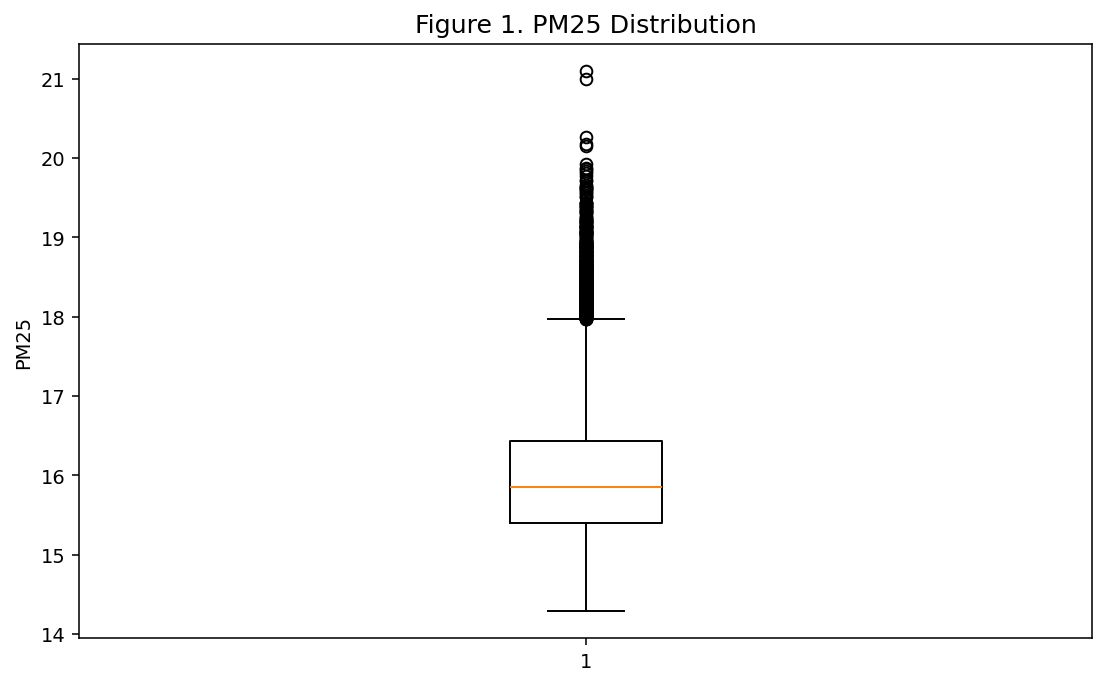

In [11]:

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(gdf['PM25'], vert=True)
ax.set_title('Figure 1. PM25 Distribution', fontsize=13)
ax.set_ylabel('PM25')

plt.tight_layout()
plt.show()

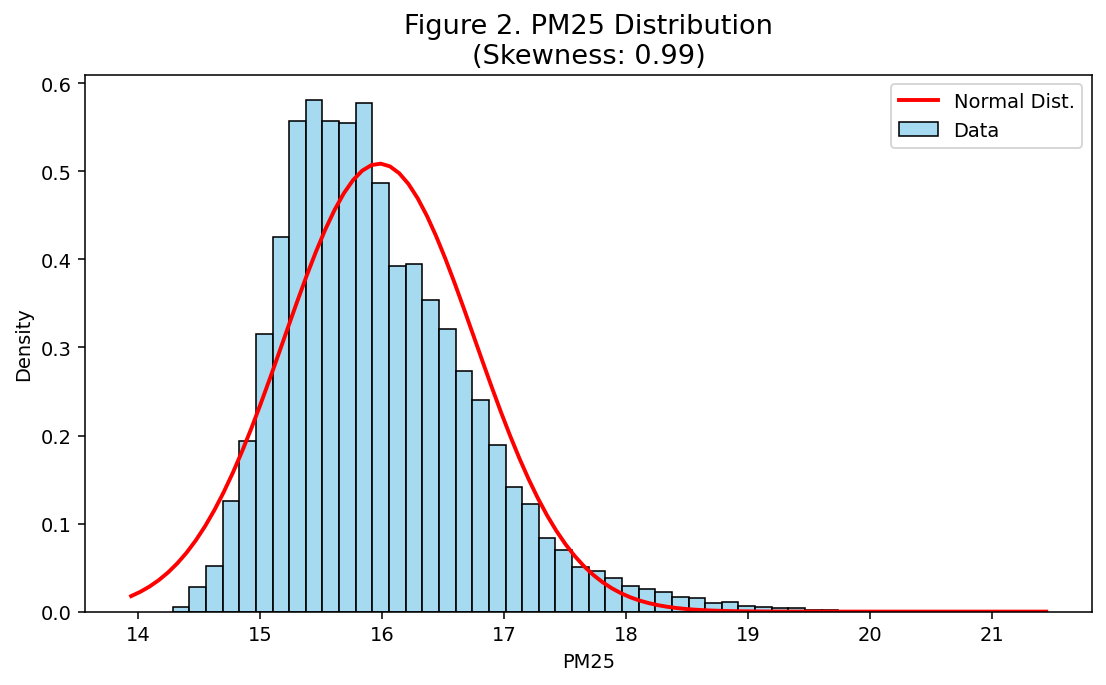

In [12]:
PM25 = gdf['PM25']

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(PM25, bins=50, kde=False, color='skyblue', stat='density', ax=ax, label='Data')

# Overlay Normal Curve
mu, std = norm.fit(PM25)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
ax.plot(x, p, 'r', linewidth=2, label='Normal Dist.')

ax.set_title(f'Figure 2. PM25 Distribution\n(Skewness: {PM25.skew():.2f})', fontsize=14)
ax.set_xlabel('PM25')
ax.legend()

plt.tight_layout()
plt.show()

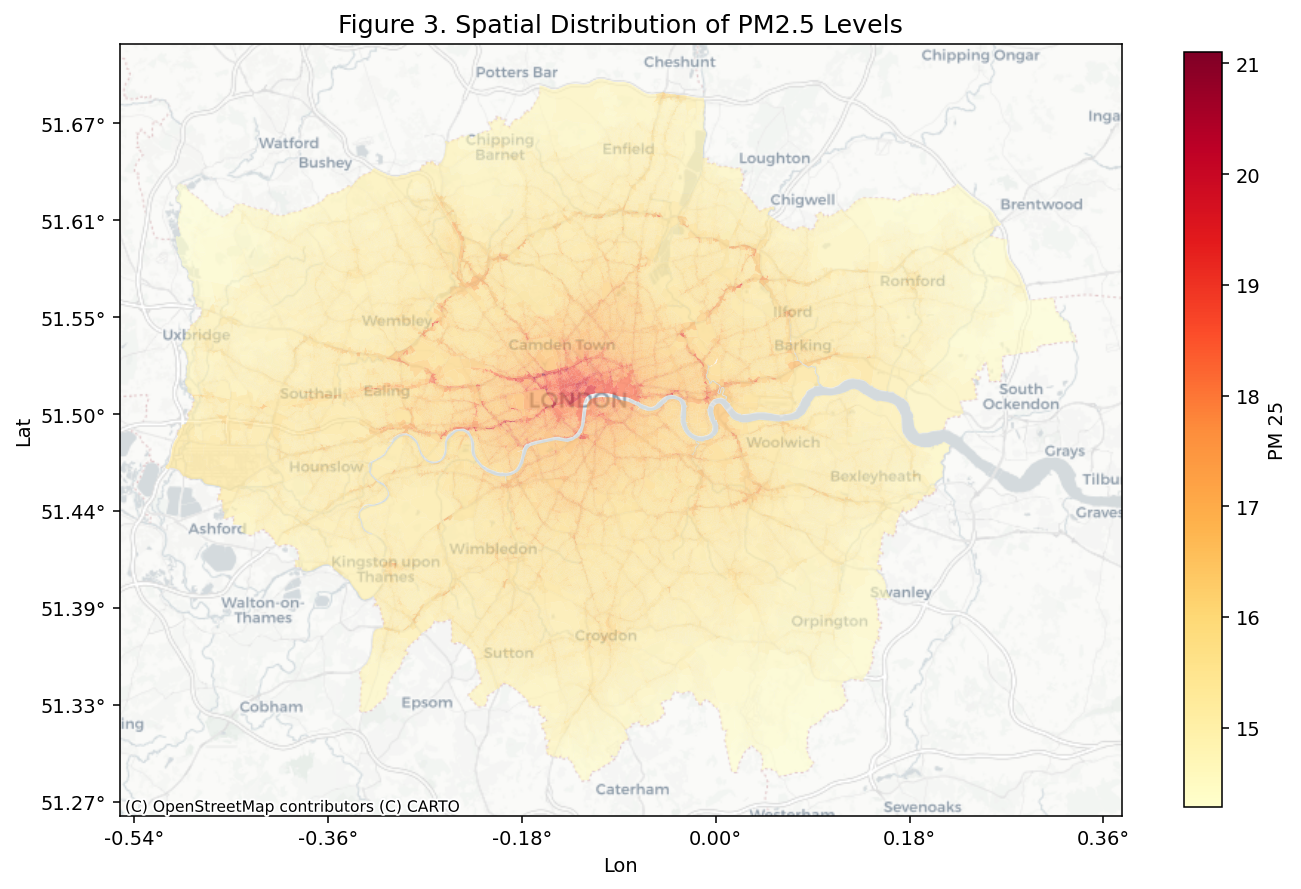

In [13]:
geometry = gdf['geometry']

gdf_web = gdf.to_crs('EPSG:3857')

fig, ax = plt.subplots(figsize=(10, 8))

gdf_web.plot(
    ax=ax, column='PM25', cmap='YlOrRd',
    markersize=5, alpha=0.6, legend=True,
    legend_kwds={'label': 'PM 25', 'shrink': 0.7}
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_xlabel('Lon')
ax.set_ylabel('Lat')

transformer = pyproj.Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)

def lon_formatter(x, pos):
    lon, _ = transformer.transform(x, 0)
    return f'{lon:.2f}°'

def lat_formatter(y, pos):
    _, lat = transformer.transform(0, y)
    return f'{lat:.2f}°'

ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
ax.set_title('Figure 3. Spatial Distribution of PM2.5 Levels', fontsize=13)

plt.tight_layout()
plt.show()

## Input Features

Input features were chosen based on previous literature around the relationship between socio-economic indicators and air pollution (beyond PM2.5), and can be seen in the table below. For example, Samoli et al (2019) found that higher population density and unemployment rates are associated with higher levels of nitrogen dioxide. Tonne et al (2018) found that exposure to air pollution in London varied by ethnic group (and by pollutant) at the residential level. They also found that travel method impacts exposure at the personal level - this report includes travel behaviour at the ward level - this is a limitation as people travel beyond their home areas, which will impact pollutant levels elsewhere. Household factors are included due to the potential for clustering of certain types of properties in more/less polluted areas.

| Variable Groups | Description |
|---|---|
| `k001_PCT-k006_PCT` | Age (mixed bands circa 5-10 years) | 
| `k007_PCT` | Population Density |
| `k008_PCT` | Lives in Communal Establishment |
| `k012_PCT - k019_PCT` | Ethnic Group |
| `k023_PCT` | Main Language is Not English |
| `k024_PCT - k026_PCT` | Household Composition (no children, no dependent children, student household) |
| `k027_PCT - k030_PCT` | House Type (detached, semi, terraced, flats) |
| `k031_PCT - k033_PCT` | Housing Tenure (owned, social rented, private rented) |
| `k041_PCT` | Car Ownership (two or more cars or vans in household) |
| `k042_PCT - k044_PCT` | Travel to Work Mode (public transport, private transport, on foot/bike/other) |
| `k045_PCT - k047_PCT` | Employment Status (unemployed, part-time, full-time) |



In [14]:
cols = ['oa_code', 'PM25', 'k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k012_PCT',
              'k013_PCT', 'k014_PCT', 'k015_PCT', 'k016_PCT',
              'k017_PCT', 'k018_PCT', 'k019_PCT', 'k023_PCT',
              'k024_PCT', 'k025_PCT', 'k026_PCT', 'k027_PCT',
              'k028_PCT', 'k029_PCT', 'k030_PCT', 'k031_PCT',
              'k032_PCT', 'k033_PCT', 'k041_PCT', 'k042_PCT',
              'k043_PCT', 'k044_PCT', 'k045_PCT', 'k046_PCT',
              'k047_PCT', 'geometry']

In [15]:
pm25_gdf = gdf[cols].copy()

In [16]:
pm25_gdf.head()

,oa_code,PM25,k001_PCT,k002_PCT,k003_PCT,k004_PCT,k005_PCT,k006_PCT,k007_RATIO,k008_PCT,...,k032_PCT,k033_PCT,k041_PCT,k042_PCT,k043_PCT,k044_PCT,k045_PCT,k046_PCT,k047_PCT,geometry
0,E00023264,16.037363,0.655567,0.733280,0.788337,0.809438,0.616867,0.048672,0.497994,0.116873,...,0.562826,0.812211,0.744820,0.759140,0.651472,0.595344,0.605881,0.605182,0.909517,"POLYGON ((527635.452 171810.058, 527495.957 17..."
1,E00003359,15.571575,0.747233,0.539689,0.833211,0.720010,0.659997,0.155885,0.389216,0.387319,...,0.513260,0.822236,0.710699,0.783003,0.805578,0.615051,0.392113,0.569934,0.923006,"POLYGON ((543581.516 171132.486, 543704 171022..."
2,E00023266,16.068834,0.689326,0.758308,0.780265,0.787414,0.633875,0.151961,0.542225,0.000000,...,0.936045,0.628015,0.356730,0.740293,0.648456,0.486254,0.659619,0.686677,0.868124,"POLYGON ((526613.539 171839.165, 526546.84 171..."
3,E00020264,18.205215,0.749280,0.701306,0.841211,0.773311,0.432955,0.000000,0.480711,0.000000,...,0.865612,0.729078,0.364842,0.789842,0.478494,0.759999,0.568907,0.516198,0.939861,"POLYGON ((533563.521 179695.146, 533351.118 17..."
4,E00023263,16.128491,0.716956,0.743201,0.823621,0.783315,0.621155,0.073256,0.532274,0.000000,...,0.777424,0.740226,0.465827,0.796597,0.610208,0.605346,0.656550,0.636807,0.895372,"POLYGON ((527822 172020, 527979 171903.001, 52..."


In [17]:
pm25_gdf.isna().sum()

oa_code       0
PM25          0
k001_PCT      0
k002_PCT      0
k003_PCT      0
k004_PCT      0
k005_PCT      0
k006_PCT      0
k007_RATIO    0
k008_PCT      0
k012_PCT      0
k013_PCT      0
k014_PCT      0
k015_PCT      0
k016_PCT      0
k017_PCT      0
k018_PCT      0
k019_PCT      0
k023_PCT      0
k024_PCT      0
k025_PCT      0
k026_PCT      0
k027_PCT      0
k028_PCT      0
k029_PCT      0
k030_PCT      0
k031_PCT      0
k032_PCT      0
k033_PCT      0
k041_PCT      0
k042_PCT      0
k043_PCT      0
k044_PCT      0
k045_PCT      0
k046_PCT      0
k047_PCT      0
geometry      0
dtype: int64

In [18]:
pm25_gdf['join_id'] = pm25_gdf['oa_code']  
id_col = 'join_id'
pm25_gdf.head()

,oa_code,PM25,k001_PCT,k002_PCT,k003_PCT,k004_PCT,k005_PCT,k006_PCT,k007_RATIO,k008_PCT,...,k033_PCT,k041_PCT,k042_PCT,k043_PCT,k044_PCT,k045_PCT,k046_PCT,k047_PCT,geometry,join_id
0,E00023264,16.037363,0.655567,0.733280,0.788337,0.809438,0.616867,0.048672,0.497994,0.116873,...,0.812211,0.744820,0.759140,0.651472,0.595344,0.605881,0.605182,0.909517,"POLYGON ((527635.452 171810.058, 527495.957 17...",E00023264
1,E00003359,15.571575,0.747233,0.539689,0.833211,0.720010,0.659997,0.155885,0.389216,0.387319,...,0.822236,0.710699,0.783003,0.805578,0.615051,0.392113,0.569934,0.923006,"POLYGON ((543581.516 171132.486, 543704 171022...",E00003359
2,E00023266,16.068834,0.689326,0.758308,0.780265,0.787414,0.633875,0.151961,0.542225,0.000000,...,0.628015,0.356730,0.740293,0.648456,0.486254,0.659619,0.686677,0.868124,"POLYGON ((526613.539 171839.165, 526546.84 171...",E00023266
3,E00020264,18.205215,0.749280,0.701306,0.841211,0.773311,0.432955,0.000000,0.480711,0.000000,...,0.729078,0.364842,0.789842,0.478494,0.759999,0.568907,0.516198,0.939861,"POLYGON ((533563.521 179695.146, 533351.118 17...",E00020264
4,E00023263,16.128491,0.716956,0.743201,0.823621,0.783315,0.621155,0.073256,0.532274,0.000000,...,0.740226,0.465827,0.796597,0.610208,0.605346,0.656550,0.636807,0.895372,"POLYGON ((527822 172020, 527979 171903.001, 52...",E00023263


## Graph Construction

A queen contiguity graph is built to represent spatial neighbours of London's wards. The queen spatial relationship assumes that nodes are neighbours if they share a common vertex or edge. This approach is relevant to the spatial distribution of PM2.5 levels as pollutants spread any direction in the air, and London wards with diagonal relationships likely share features that expose them to pollutants, such as road networks. Figure 4 visualises the graph network, and shows that inner ward nodes are highly clustered while peripheral areas are more dispersed, as expected.

In [19]:
def build_contiguity_graph(polys_gdf: gpd.GeoDataFrame, id_col: str, kind: str = "queen") -> nx.Graph:
    """Build a contiguity graph from polygon geometries.

    Queen: touches at a point or edge.
    Rook: shares a boundary segment (non-zero length).
    """
    assert kind in {"queen", "rook"}
    Gc = nx.Graph()
    Gc.add_nodes_from(polys_gdf[id_col].tolist())

    sindex = polys_gdf.sindex
    geoms = polys_gdf.geometry.values
    ids = polys_gdf[id_col].values

    for i, geom_i in enumerate(geoms):
        cand_idx = list(sindex.intersection(geom_i.bounds))
        for j in cand_idx:
            if j <= i:
                continue
            geom_j = geoms[j]

            if kind == "queen":
                if geom_i.touches(geom_j):
                    Gc.add_edge(ids[i], ids[j])
            else:  # rook
                inter = geom_i.boundary.intersection(geom_j.boundary)
                if (not inter.is_empty) and getattr(inter, "length", 0.0) > 0:
                    Gc.add_edge(ids[i], ids[j])

    return Gc


contiguity = "queen"
G_queen = build_contiguity_graph(pm25_gdf, id_col=id_col, kind="queen")

G_queen.number_of_nodes(), G_queen.number_of_edges()


(25053, 75967)

In [20]:
# Compare connectivity
print("Queen connected?", nx.is_connected(G_queen))
print("\nQueen components:", nx.number_connected_components(G_queen))

Queen connected? True

Queen components: 1


<Figure size 868x868 with 0 Axes>

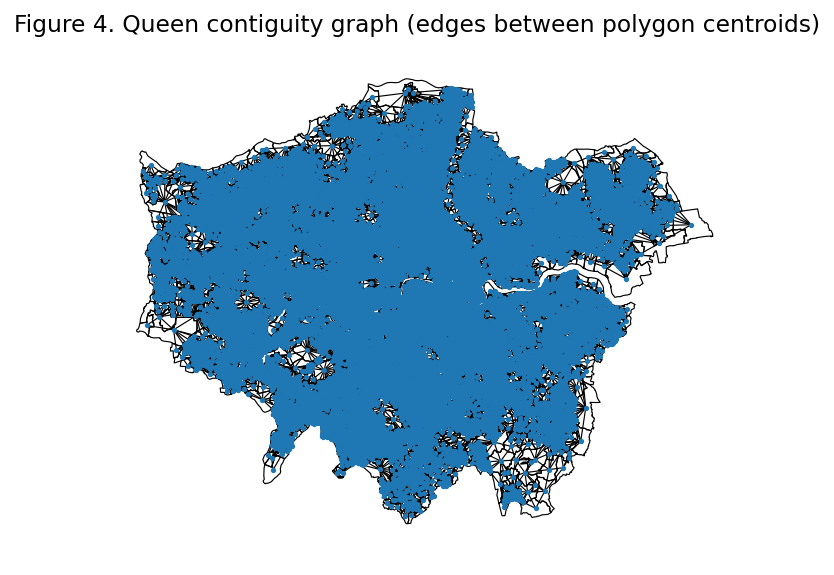

In [21]:
# Visualise adjacency graphs on the map (edges drawn between polygon centroids)
pm25_gdf["centroid"] = pm25_gdf.geometry.centroid
centroid_pos = {row[id_col]: (row["centroid"].x, row["centroid"].y) for _, row in pm25_gdf.iterrows()}

def plot_map_with_graph(polys_gdf, graph, title):
    plt.figure(figsize=(6.2, 6.2))
    ax = polys_gdf.plot(edgecolor="black", linewidth=0.6, facecolor="none")
    nx.draw(graph, pos=centroid_pos, node_size=3, width=0.6, ax=ax)
    plt.title(title)
    plt.axis("off")
    plt.show()

plot_map_with_graph(pm25_gdf, G_queen, "Figure 4. Queen contiguity graph (edges between polygon centroids)")



## Graph Neural Network Model

GraphSAGE is the GNN model selected. GraphSAGE is said to be advantageous over GCN for its ability to generalise predicitons to unseen nodes, take less computational power, and be more scalable (de Harder, 2025).

In [22]:
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

def make_masks(num_nodes: int, train_ratio=0.6, val_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(num_nodes)
    rng.shuffle(idx)
    n_train = int(train_ratio * num_nodes)
    n_val = int(val_ratio * num_nodes)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask

def accuracy(logits, y):
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()

@torch.no_grad()
def evaluate_classification(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    acc_train = accuracy(out[data.train_mask], data.y[data.train_mask])
    acc_val   = accuracy(out[data.val_mask], data.y[data.val_mask])
    acc_test  = accuracy(out[data.test_mask], data.y[data.test_mask])
    return acc_train, acc_val, acc_test

@torch.no_grad()
def evaluate_regression(model, data):
    model.eval()
    pred = model(data.x, data.edge_index).view(-1)
    y = data.y.view(-1)
    def rmse(mask):
        return torch.sqrt(F.mse_loss(pred[mask], y[mask])).item()
    return rmse(data.train_mask), rmse(data.val_mask), rmse(data.test_mask)

@torch.no_grad()
def evaluate_regression_r2(model, data):
    model.eval()
    pred = model(data.x, data.edge_index).view(-1)
    y = data.y.view(-1)

    def r2(mask):
        y_true = y[mask]
        y_pred = pred[mask]
        ss_res = torch.sum((y_true - y_pred) ** 2)
        ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
        return (1 - ss_res / (ss_tot + 1e-12)).item()

    return r2(data.train_mask), r2(data.val_mask), r2(data.test_mask)


def plot_learning_curve(train_vals, val_vals, title, ylabel):
    plt.figure(figsize=(5.5, 3.2))
    plt.plot(train_vals, label="train")
    plt.plot(val_vals, label="val")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

In [23]:
def train_node_regression(model, data, lr=0.01, weight_decay=1e-4, epochs=150):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_rmse, val_rmse = [], []
    for epoch in range(1, epochs+1):
        model.train()
        optimizer.zero_grad()
        pred = model(data.x, data.edge_index).view(-1)
        y = data.y.view(-1)
        loss = F.mse_loss(pred[data.train_mask], y[data.train_mask])
        loss.backward()
        optimizer.step()

        r_train, r_val, _ = evaluate_regression(model, data)
        train_rmse.append(r_train)
        val_rmse.append(r_val)

        if epoch % 30 == 0:
            print(f"epoch {epoch:3d} | loss {loss.item():.4f} | rmse train {r_train:.4f} | val {r_val:.4f}")
    return train_rmse, val_rmse


In [24]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3, aggr="mean"):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim, aggr=aggr)
        self.conv2 = SAGEConv(hidden_dim, out_dim, aggr=aggr)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x
class SAGEReg(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=32, dropout=0.2, aggr="mean"):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim, aggr=aggr)
        self.conv2 = SAGEConv(hidden_dim, 1, aggr=aggr)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x



In [25]:
# Features — everything except PM25, geometry, and centroid columns
feature_cols = [col for col in pm25_gdf.columns if col not in ['PM25', 'geometry', 'centroid', 'join_id']]
# Coerce to numeric where possible
for c in feature_cols:
    pm25_gdf[c] = pd.to_numeric(pm25_gdf[c], errors="coerce")
numeric_feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(pm25_gdf[c])]
print("Numeric feature columns:", len(numeric_feature_cols))

# Target: try to detect a single numeric target column (excluding join_id)
target_cols = ['PM25']
numeric_target_cols = [c for c in target_cols if pd.api.types.is_numeric_dtype(pm25_gdf[c])]
print("Numeric target columns:", numeric_target_cols)

# Choose target column (default: first numeric target column)
target_col = numeric_target_cols[0] if len(numeric_target_cols) > 0 else None
target_col


Numeric feature columns: 35
Numeric target columns: ['PM25']


'PM25'

In [26]:
# Missingness
miss_feat = pm25_gdf[numeric_feature_cols].isna().mean().sort_values(ascending=False)
miss_target = pm25_gdf[[target_col]].isna().mean()

print("Top missingness (features):")
print(miss_feat.head(10))
print("\nMissingness (target):")
print(miss_target)


Top missingness (features):
oa_code       1.0
k001_PCT      0.0
k002_PCT      0.0
k003_PCT      0.0
k004_PCT      0.0
k005_PCT      0.0
k006_PCT      0.0
k007_RATIO    0.0
k008_PCT      0.0
k012_PCT      0.0
dtype: float64

Missingness (target):
PM25    0.0
dtype: float64


In [27]:
# Basic descriptive stats
desc_feat = pm25_gdf[numeric_feature_cols].describe().T
desc_tgt  = pm25_gdf[[target_col]].describe().T
desc_feat.head(12), desc_tgt

(              count      mean       std  min       25%       50%       75%  \
 oa_code         0.0       NaN       NaN  NaN       NaN       NaN       NaN   
 k001_PCT    25053.0  0.641684  0.110625  0.0  0.582274  0.653091  0.715548   
 k002_PCT    25053.0  0.707470  0.130594  0.0  0.657844  0.736098  0.792400   
 k003_PCT    25053.0  0.794843  0.069501  0.0  0.750909  0.793896  0.840683   
 k004_PCT    25053.0  0.804916  0.070901  0.0  0.770634  0.813506  0.851794   
 k005_PCT    25053.0  0.562638  0.129298  0.0  0.498177  0.575978  0.646634   
 k006_PCT    25053.0  0.094603  0.113678  0.0  0.000000  0.067458  0.141239   
 k007_RATIO  25053.0  0.475044  0.079349  0.0  0.437683  0.481625  0.523587   
 k008_PCT    25053.0  0.045306  0.147087  0.0  0.000000  0.000000  0.000000   
 k012_PCT    25053.0  0.861921  0.111133  0.0  0.810606  0.893054  0.943952   
 k013_PCT    25053.0  0.566945  0.154331  0.0  0.480512  0.588330  0.675739   
 k014_PCT    25053.0  0.362711  0.224310  0.0  0.199

In [28]:
# Prepare X and y, aligned to GeoJSON order
node_order = pm25_gdf[id_col].tolist()
feat_aligned = pm25_gdf.set_index(id_col).loc[node_order, numeric_feature_cols]
tgt_aligned  = pm25_gdf.set_index(id_col).loc[node_order, target_col]

# Impute missing feature values with 0 (teaching default); consider better strategies in real projects
X_df = feat_aligned.fillna(0.0).astype(float)

# Standardise features (z-score) for training stability
X_std = (X_df - X_df.mean()) / (X_df.std() + 1e-8)
X = torch.tensor(X_std.values, dtype=torch.float32)

# Target: impute missing with mean (or drop nodes in real workflow)
y_series = tgt_aligned.astype(float)
y_filled = y_series.fillna(y_series.mean())
y = torch.tensor(y_filled.values, dtype=torch.float32).view(-1, 1)

print("X:", X.shape, "| y:", y.shape)

X: torch.Size([25053, 35]) | y: torch.Size([25053, 1])


In [29]:
# Build edge_index in PyG format (bidirectional)
node_to_idx = {n:i for i,n in enumerate(node_order)}
edges = []
for u, v in G_queen.edges():
    edges.append((node_to_idx[u], node_to_idx[v]))
    edges.append((node_to_idx[v], node_to_idx[u]))
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

data_poly = Data(x=X, edge_index=edge_index, y=y)
data_poly.train_mask, data_poly.val_mask, data_poly.test_mask = make_masks(data_poly.num_nodes, 0.6, 0.2, seed=42)
data_poly

Data(x=[25053, 35], edge_index=[2, 151934], y=[25053, 1], train_mask=[25053], val_mask=[25053], test_mask=[25053])

In [30]:
pm25_gdf.head()

,oa_code,PM25,k001_PCT,k002_PCT,k003_PCT,k004_PCT,k005_PCT,k006_PCT,k007_RATIO,k008_PCT,...,k041_PCT,k042_PCT,k043_PCT,k044_PCT,k045_PCT,k046_PCT,k047_PCT,geometry,join_id,centroid
0,NaN,16.037363,0.655567,0.733280,0.788337,0.809438,0.616867,0.048672,0.497994,0.116873,...,0.744820,0.759140,0.651472,0.595344,0.605881,0.605182,0.909517,"POLYGON ((527635.452 171810.058, 527495.957 17...",E00023264,POINT (527526.428 171947.689)
1,NaN,15.571575,0.747233,0.539689,0.833211,0.720010,0.659997,0.155885,0.389216,0.387319,...,0.710699,0.783003,0.805578,0.615051,0.392113,0.569934,0.923006,"POLYGON ((543581.516 171132.486, 543704 171022...",E00003359,POINT (543811.648 170949.578)
2,NaN,16.068834,0.689326,0.758308,0.780265,0.787414,0.633875,0.151961,0.542225,0.000000,...,0.356730,0.740293,0.648456,0.486254,0.659619,0.686677,0.868124,"POLYGON ((526613.539 171839.165, 526546.84 171...",E00023266,POINT (526679.771 171864.076)
3,NaN,18.205215,0.749280,0.701306,0.841211,0.773311,0.432955,0.000000,0.480711,0.000000,...,0.364842,0.789842,0.478494,0.759999,0.568907,0.516198,0.939861,"POLYGON ((533563.521 179695.146, 533351.118 17...",E00020264,POINT (533513.69 179855.843)
4,NaN,16.128491,0.716956,0.743201,0.823621,0.783315,0.621155,0.073256,0.532274,0.000000,...,0.465827,0.796597,0.610208,0.605346,0.656550,0.636807,0.895372,"POLYGON ((527822 172020, 527979 171903.001, 52...",E00023263,POINT (527863.192 171936.823)


epoch  30 | loss 12.1705 | rmse train 3.2042 | val 3.2119
epoch  60 | loss 3.7282 | rmse train 1.6105 | val 1.6173
epoch  90 | loss 2.3307 | rmse train 1.2038 | val 1.2244
epoch 120 | loss 1.8091 | rmse train 1.0010 | val 1.0197
epoch 150 | loss 1.4622 | rmse train 0.8674 | val 0.8816
epoch 180 | loss 1.2458 | rmse train 0.7718 | val 0.7840
epoch 210 | loss 1.0785 | rmse train 0.7034 | val 0.7160
epoch 240 | loss 0.9981 | rmse train 0.6522 | val 0.6648
epoch 270 | loss 0.8714 | rmse train 0.6131 | val 0.6270
epoch 300 | loss 0.8418 | rmse train 0.5804 | val 0.5930
epoch 330 | loss 0.7561 | rmse train 0.5521 | val 0.5671
epoch 360 | loss 0.7017 | rmse train 0.5303 | val 0.5446
epoch 390 | loss 0.6899 | rmse train 0.5096 | val 0.5236
epoch 420 | loss 0.6627 | rmse train 0.4917 | val 0.5048
epoch 450 | loss 0.6243 | rmse train 0.4780 | val 0.4906
epoch 480 | loss 0.6117 | rmse train 0.4642 | val 0.4756
epoch 510 | loss 0.6009 | rmse train 0.4541 | val 0.4665
epoch 540 | loss 0.5759 | rmse

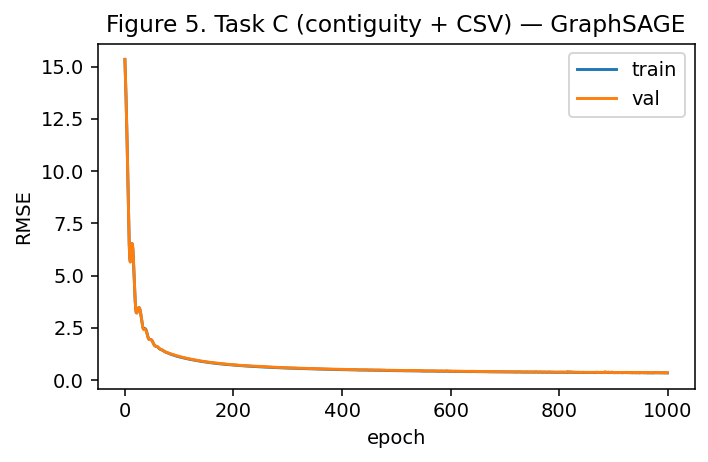

In [31]:
sage_reg_poly = SAGEReg(in_dim=data_poly.x.size(1), hidden_dim=64, dropout=0.2, aggr="mean")
train_rmse_sage_poly, val_rmse_sage_poly = train_node_regression(sage_reg_poly, data_poly, epochs=1000)
print("Final (GraphSAGE) RMSE train/val/test:", evaluate_regression(sage_reg_poly, data_poly))
print("Final (GraphSAGE) R2 train/val/test:", evaluate_regression_r2(sage_reg_poly, data_poly))
plot_learning_curve(train_rmse_sage_poly, val_rmse_sage_poly, "Figure 5. Task C (contiguity + CSV) — GraphSAGE", "RMSE")



The Root Mean Square Error value is around 0.3558 - this means the model's predictions are, on average, around 0.3558 μg/m3 off the actual value (around 5%). With a range of PM2.5 levels of around 6.82 μg/m3, this suggests the model predicts with a reasonable level of accuracy. The R-squared is about 0.78 indicating the model accounts for c. 78% of the variance in PM2.5 levels.

Figure 5 shows that the training and validation RMSE's converged closely, indicating that the model generalises to new data well without overfitting.

## OLS Model 

An OLS model is specified using the same data to allow comparison between model performance. As OLS assumes variables are independent, a spatial weights matrix is created to allow spatial diagnostic checks to be carried out. Variance Inflation Factor checks are also carried out to see if multicollinearity is a problem.

In [32]:
#OLS model 

ols_cols = ['oa_code', 'PM25', 'k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k012_PCT',
              'k013_PCT', 'k014_PCT', 'k015_PCT', 'k016_PCT',
              'k017_PCT', 'k018_PCT', 'k019_PCT', 'k023_PCT',
              'k024_PCT', 'k025_PCT', 'k026_PCT', 'k027_PCT',
              'k028_PCT', 'k029_PCT', 'k030_PCT', 'k031_PCT',
              'k032_PCT', 'k033_PCT', 'k041_PCT', 'k042_PCT',
              'k043_PCT', 'k044_PCT', 'k045_PCT', 'k046_PCT',
              'k047_PCT', 'geometry']



pm25_ols = pm25_gdf[ols_cols].copy()


In [33]:
from libpysal.weights import DistanceBand, KNN
# Extract projected coordinates for distance calculations
pm25_ols = pm25_ols.to_crs('EPSG:27700')
coords = np.column_stack((pm25_ols.geometry.centroid.x, pm25_ols.geometry.centroid.y))

# ---- KNN Weight Matrix ----
w_knn = KNN.from_array(coords, k=5)
w_knn.transform = 'R'  # Row-standardise

print("=== KNN Spatial Weights (k=5) ===")
print(f"Number of observations: {w_knn.n}")
print(f"Mean number of neighbours: {w_knn.mean_neighbors:.1f}")
print(f"Min neighbours: {w_knn.min_neighbors}")
print(f"Max neighbours: {w_knn.max_neighbors}")

=== KNN Spatial Weights (k=5) ===
Number of observations: 25053
Mean number of neighbours: 5.0
Min neighbours: 5
Max neighbours: 5


In [34]:
# Dependent variable
y_col = 'PM25'
y_ols = pm25_ols[[y_col]].values


x_cols = ['k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k012_PCT',
              'k013_PCT', 'k014_PCT', 'k015_PCT', 'k016_PCT',
              'k017_PCT', 'k018_PCT', 'k019_PCT', 'k023_PCT',
              'k024_PCT', 'k025_PCT', 'k026_PCT', 'k027_PCT',
              'k028_PCT', 'k029_PCT', 'k030_PCT', 'k031_PCT',
              'k032_PCT', 'k033_PCT', 'k041_PCT', 'k042_PCT',
              'k043_PCT', 'k044_PCT', 'k045_PCT', 'k046_PCT',
              'k047_PCT']

x = pm25_ols[x_cols].values


In [35]:
#%pip install statsmodels
# VIF Check for Multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe of just the independent variables (X)
X_vif = pm25_ols[x_cols] 

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factor (VIF) Check:")
print("-" * 40)
print(vif_data.sort_values('VIF', ascending=False))
print("-" * 40)
print("Note: VIF > 10 indicates high multicollinearity that may distort spatial coefficients.")

Variance Inflation Factor (VIF) Check:
----------------------------------------
      Variable          VIF
33    k047_PCT  1100.757474
2     k003_PCT   884.911417
3     k004_PCT   367.613229
8     k012_PCT   227.640339
28    k042_PCT   213.420208
29    k043_PCT   175.607571
24    k031_PCT   172.090078
32    k046_PCT   161.806643
17    k024_PCT    99.107109
1     k002_PCT    86.477102
27    k041_PCT    81.391289
26    k033_PCT    80.007248
6   k007_RATIO    63.558720
0     k001_PCT    61.598979
4     k005_PCT    56.467565
30    k044_PCT    49.155760
18    k025_PCT    46.364609
23    k030_PCT    40.536885
31    k045_PCT    34.733705
9     k013_PCT    22.408984
14    k018_PCT    21.011622
25    k032_PCT    19.579281
21    k028_PCT    16.680235
16    k023_PCT    14.005407
13    k017_PCT    13.980198
22    k029_PCT     9.023789
10    k014_PCT     8.319749
15    k019_PCT     6.886226
20    k027_PCT     6.230912
11    k015_PCT     3.588740
5     k006_PCT     2.832300
12    k016_PCT     2.546

In [36]:
x_cols_update = ['k001_PCT', 'k002_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT',
              'k013_PCT', 'k014_PCT', 'k015_PCT', 'k016_PCT',
              'k017_PCT', 'k018_PCT', 'k019_PCT', 'k023_PCT',
              'k025_PCT', 'k026_PCT', 'k027_PCT',
              'k028_PCT', 'k029_PCT', 'k030_PCT',
              'k032_PCT', 'k033_PCT', 'k041_PCT',
              'k044_PCT', 'k045_PCT',
              ]  #remove 047, 003, 004, 012, 042, 043, 031, 046, 024 now due to very high VIF

# Create a dataframe of just the independent variables (X)
X_vif = pm25_ols[x_cols_update] 

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factor (VIF) Check:")
print("-" * 40)
print(vif_data.sort_values('VIF', ascending=False))
print("-" * 40)
print("Note: VIF > 10 indicates high multicollinearity that may distort spatial coefficients.")

Variance Inflation Factor (VIF) Check:
----------------------------------------
      Variable        VIF
1     k002_PCT  72.147404
21    k033_PCT  59.053473
0     k001_PCT  52.977912
22    k041_PCT  51.504369
4   k007_RATIO  50.185857
14    k025_PCT  42.738251
19    k030_PCT  38.646279
2     k005_PCT  36.206931
23    k044_PCT  31.849832
24    k045_PCT  31.136635
6     k013_PCT  21.658220
11    k018_PCT  18.834105
20    k032_PCT  16.993286
17    k028_PCT  15.920785
10    k017_PCT  13.435152
13    k023_PCT  12.512805
18    k029_PCT   8.517510
7     k014_PCT   7.192036
12    k019_PCT   6.682976
16    k027_PCT   5.959833
8     k015_PCT   3.317567
3     k006_PCT   2.622592
9     k016_PCT   2.393024
15    k026_PCT   1.968505
5     k008_PCT   1.272935
----------------------------------------
Note: VIF > 10 indicates high multicollinearity that may distort spatial coefficients.


In [37]:
x_cols_update = ['k006_PCT', 'k008_PCT',
               'k014_PCT', 'k015_PCT', 'k016_PCT',
              'k019_PCT',
              'k026_PCT', 'k027_PCT',
              'k028_PCT', 'k029_PCT',
              'k032_PCT',
            
              ]  #remove 047, 003, 004, 012, 042, 043, 031, 046, 024 now due to very high VIF 
              #second time remove 002, 033, 001, 041, 007, k025, k030, k005, k044, k045, k013, k018
              #third time remove k017, k023

# Create a dataframe of just the independent variables (X)
X_vif = pm25_ols[x_cols_update] 

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factor (VIF) Check:")
print("-" * 40)
print(vif_data.sort_values('VIF', ascending=False))
print("-" * 40)
print("Note: VIF > 10 indicates high multicollinearity that may distort spatial coefficients.")

Variance Inflation Factor (VIF) Check:
----------------------------------------
    Variable       VIF
8   k028_PCT  8.904558
9   k029_PCT  6.560687
2   k014_PCT  5.517626
10  k032_PCT  5.295748
7   k027_PCT  4.918168
5   k019_PCT  4.554098
3   k015_PCT  2.962561
4   k016_PCT  1.951860
0   k006_PCT  1.894715
6   k026_PCT  1.631037
1   k008_PCT  1.215082
----------------------------------------
Note: VIF > 10 indicates high multicollinearity that may distort spatial coefficients.


High levels of multicollinearity were found for many variables - therefore, variables with a score over 10 were gradually removed.

In [38]:
# Update X with the new set of independent variables
x_cols = x_cols_update
x_ols = pm25_ols[x_cols].values

In [39]:
from spreg import OLS
# Run OLS
ols = OLS(
    y_ols, x_ols,
    w=w_knn,
    name_y=y_col,
    name_x=x_cols,
    name_ds='London PM2.5 and London OAC',
    spat_diag=True  # Request spatial diagnostics including LM tests
)

print(ols.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :London PM2.5 and London OAC
Weights matrix      :     unknown
Dependent Variable  :        PM25                Number of Observations:       25053
Mean dependent var  :     15.9756                Number of Variables   :          12
S.D. dependent var  :      0.7840                Degrees of Freedom    :       25041
R-squared           :      0.5345
Adjusted R-squared  :      0.5343
Sum squared residual:      7167.6                F-statistic           :   2613.7603
Sigma-square        :       0.286                Prob(F-statistic)     :           0
S.E. of regression  :       0.535                Log likelihood        :  -19872.716
Sigma-square ML     :       0.286                Akaike info criterion :   39769.432
S.E of regression ML:      0.5349                Schwarz criterion     :   39866.977

---------------------------------------------

## Results 

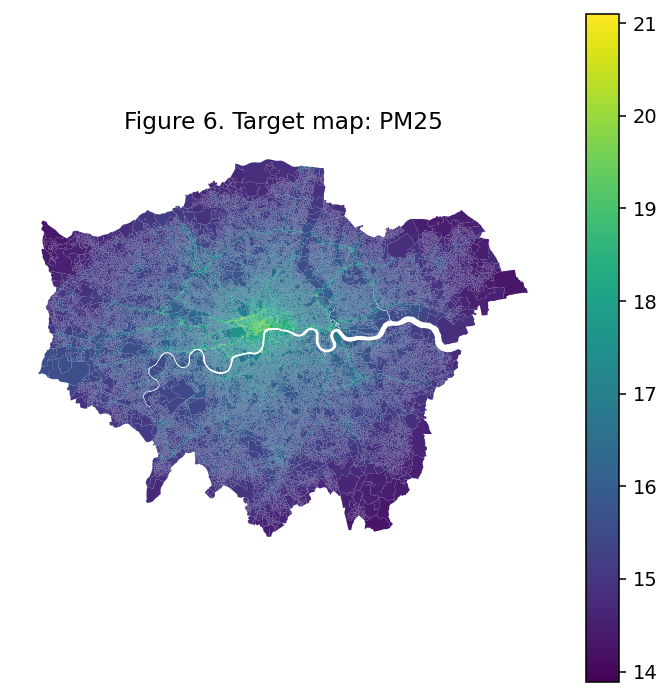

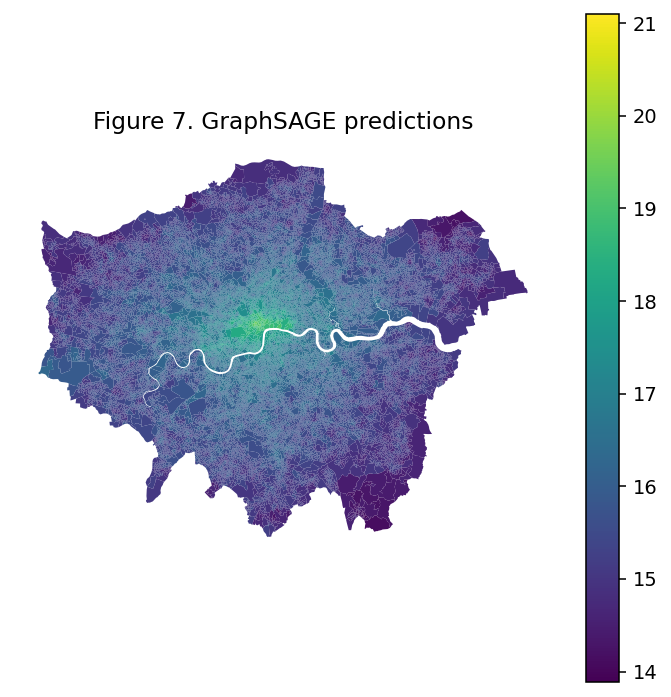

In [44]:
@torch.no_grad()
def predict_reg(model, data):
    model.eval()
    return model(data.x, data.edge_index).view(-1).cpu().numpy()

pm25_gdf_plot = pm25_gdf.copy()
pm25_gdf_plot["target"] = y.view(-1).cpu().numpy()

# GraphSAGE
pm25_gdf_plot["pred_sage"] = predict_reg(sage_reg_poly, data_poly)

vmin = min(pm25_gdf_plot["target"].min(), pm25_gdf_plot["pred_sage"].min())
vmax = max(pm25_gdf_plot["target"].max(), pm25_gdf_plot["pred_sage"].max())

# Plot: target
ax = pm25_gdf_plot.plot(column="target", legend=True, figsize=(6.2, 6.2), vmin = vmin, vmax=vmax)
ax.set_title(f"Figure 6. Target map: {target_col}")
ax.axis("off")
plt.show()

# Plot: GraphSAGE prediction
ax = pm25_gdf_plot.plot(column="pred_sage", legend=True, figsize=(6.2, 6.2), vmin = vmin, vmax = vmax)
ax.set_title("Figure 7. GraphSAGE predictions")
ax.axis("off")
plt.show()


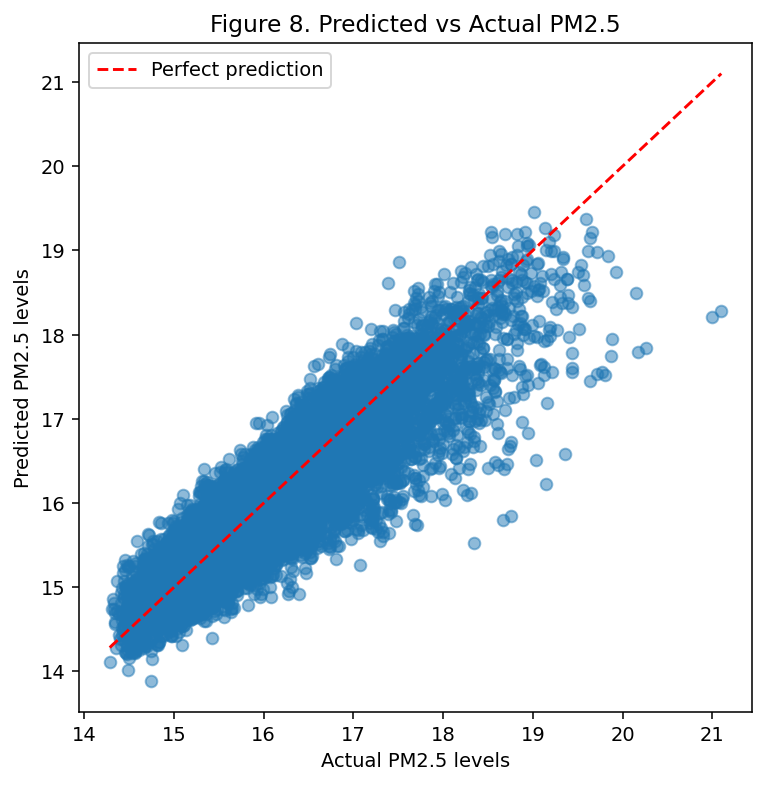

In [45]:
actual = pm25_gdf_plot["target"]
pred = pm25_gdf_plot["pred_sage"]

plt.figure(figsize=(6.2, 6.2))
plt.scatter(actual, pred, alpha=0.5)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual PM2.5 levels')
plt.ylabel('Predicted PM2.5 levels')
plt.title('Figure 8. Predicted vs Actual PM2.5')
plt.legend()
plt.show()

Figure 6 shows the target map of the actual distribution of PM2.5 levels across London, while Figure 7 shows the GraphSAGE prediciton. Figure 8 shows an actual vs predicted plot. Comparing the results, the model predictions seems to follow the observed trend with higher pollution levels predicted in central areas, which gradually reduce as wards get closer to the city boundary. This suggests that the GraphSAGE model is able to predict PM2.5 level reasonably well across most of the distribution using selected sociodemographic data. However, the target map shows a clustering of higher values around Central London than the predicted map, indicating the model has underpredicted extremely high values. The target map also hows high values around major road networks, which the predicted map has failed to capture. Figure 8 confirms this trend - the actual PM2.5 values go up to over 21 μg/m3, while the highest predicted value is around 19.5 μg/m3. This could be a result of oversmoothing due to GraphSAGE networks aggregation methods across queen contiguity neighbours - the model aggregates the mean of neighbouring wards which can dilute extreme values. This has important practical implications for air quality modelling, where extremely high pollution values are of policy importance. 

### Comparison with OLS

As previously mentioned, the OLS model required the removal of many variables, which could lead to omitted variable bias- the GNN is not held to the same assumptions and so was able to include these potentially important input features. The remaining variables in the OLS make the model difficult to interpret, for example, the only age band retained is people aged 90 and over. Further, the spatial diagnostic results show significant spatial dependence, meaning the coefficients cannot be reliably interpreted, which suggests the model is missing important spatial information. The GNN model, on the other hand, uses spatial relationships to help its predictive power, and shows it better suitability to this dataset. However, the GraphSAGE model does not reveal the impact of individual determinants as OLS can (when properly specified).

Overall, this report has used a GraphSAGE model to predict PM2.5 levels across London wards using a variety of census data. The model has been found to perform reasonably well, especially compared to an OLS model. However, under prediction of extreme values remains a problem. 



# References

de Harder, Hennie (2025) Graph Neural Networks Part 3: How GraphSAGE Handles Changing Graph Structure. *Towards Data Science*. Available at: https://towardsdatascience.com/graph-neural-networks-part-3-how-graphsage-handles-changing-graph-structure/ (Accessed 24/03/2026).

Samoli, E., Stergiopoulou, A., Santana, P., Rodopoulou, S., Mitsakou, C., Dimitroulopoulou, C., Bauwelinck, M., de Hoogh, K., Costa, C., Marí-Dell'Olmo, M. and Corman, D. (2019). Spatial variability in air pollution exposure in relation to socioeconomic indicators in nine European metropolitan areas: A study on environmental inequality. *Environmental Pollution*, 249, pp.345-353.

Tonne, C., Milà, C., Fecht, D., Alvarez, M., Gulliver, J., Smith, J., Beevers, S., Anderson, H.R. and Kelly, F., 2018. Socioeconomic and ethnic inequalities in exposure to air and noise pollution in London. *Environment international*, 115, pp.170-179.